[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ All libraries imported successfully!
📦 Dataset Loaded!
Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
📊 EXPLORATORY DATA ANALYSIS

📌 Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.41%
Ham  %: 86.59%

📏 Message Length Stats:
      message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0   
spam           747.0  138.670683  28.873603  13.0  133.0  149.0  157

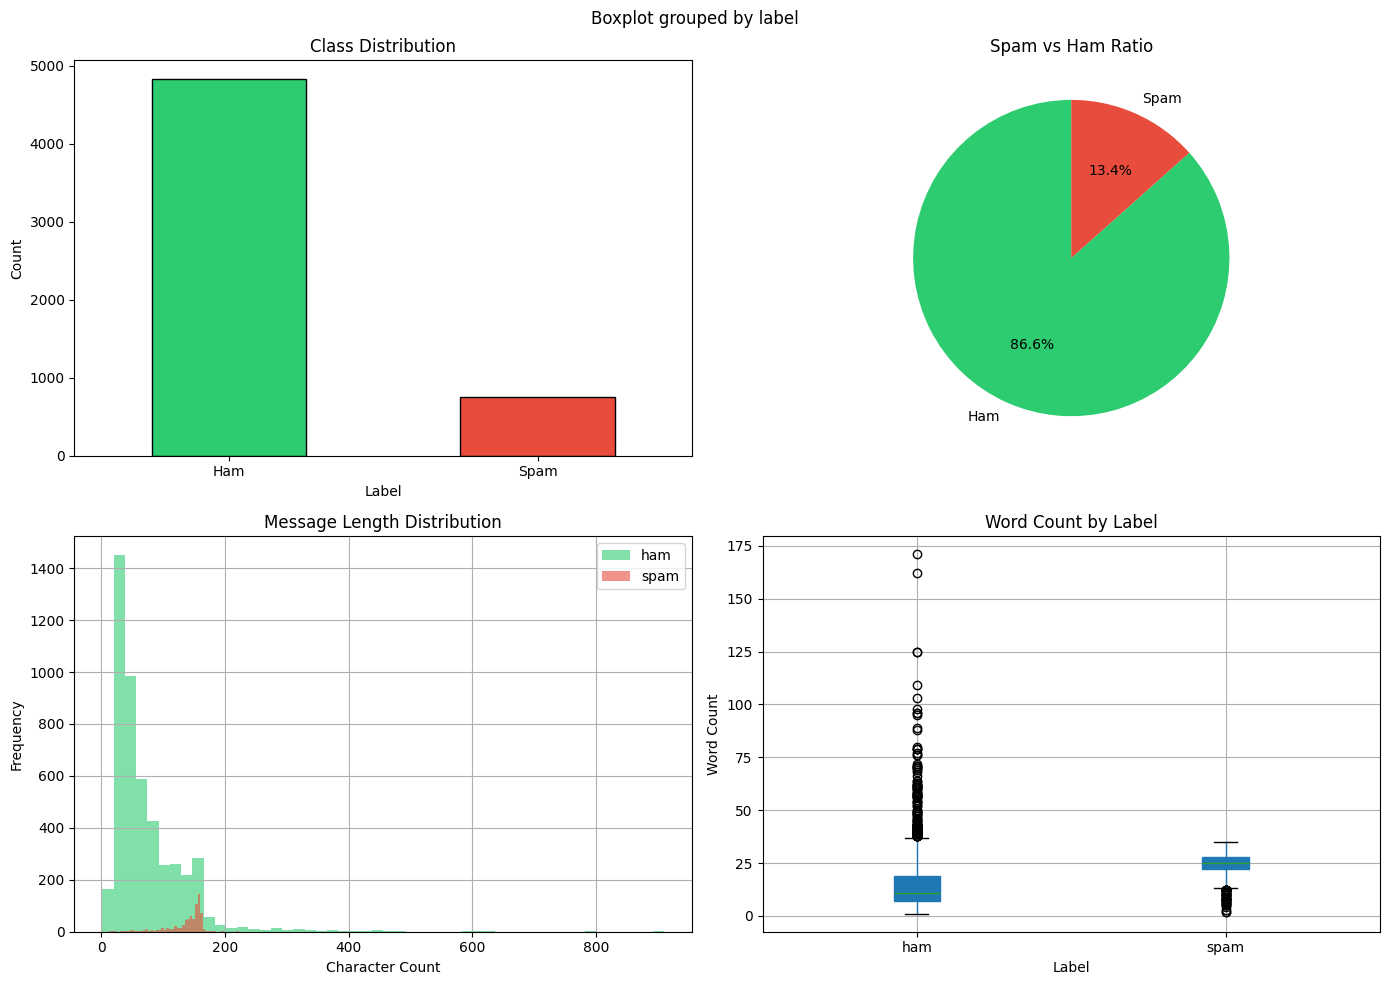

✅ EDA complete!


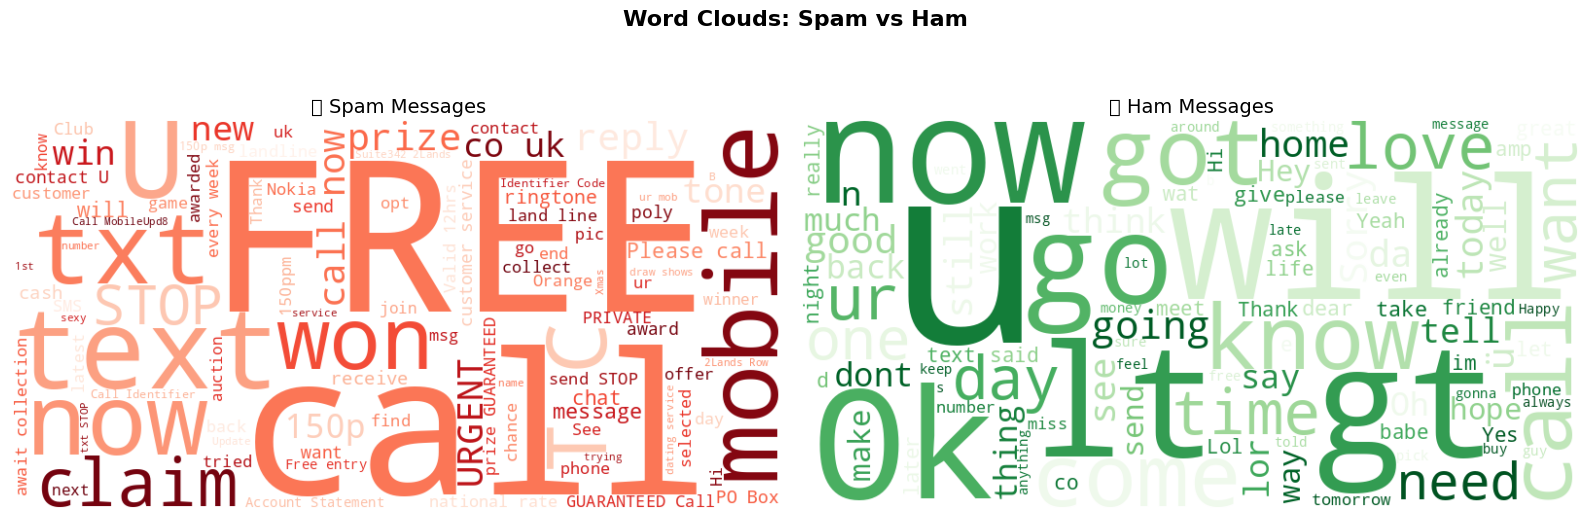

✅ Word clouds generated!
⏳ Preprocessing messages...

📌 Sample Preprocessing Results:

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : jurong point crazi avail bugi great world buffet cine got amor wat

Original : Ok lar... Joking wif u oni...
Cleaned  : lar joke wif oni

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entri wkli comp win cup final tkt may text receiv entri questionstd txt ratetc appli over

✅ Text preprocessing complete!
✅ Train size: 4457 | Test size: 1115
   Spam in train: 598 | Spam in test: 149
🔬 MODEL TRAINING & EVALUATION

🔹 Naive Bayes (MNB)
   Accuracy : 0.9776 (97.76%)
   ROC-AUC  : 0.9801
   Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.86  

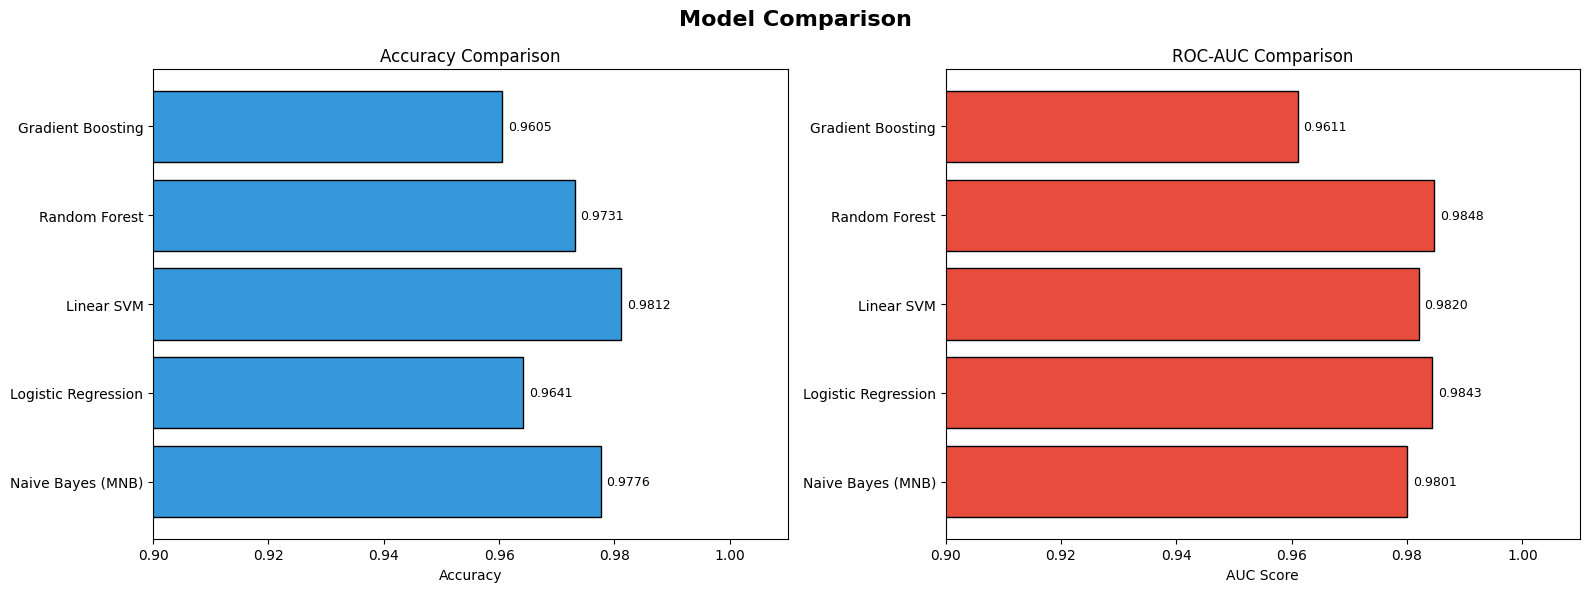

✅ Model comparison complete!
🏆 Best Model: Linear SVM (Accuracy: 0.9812)


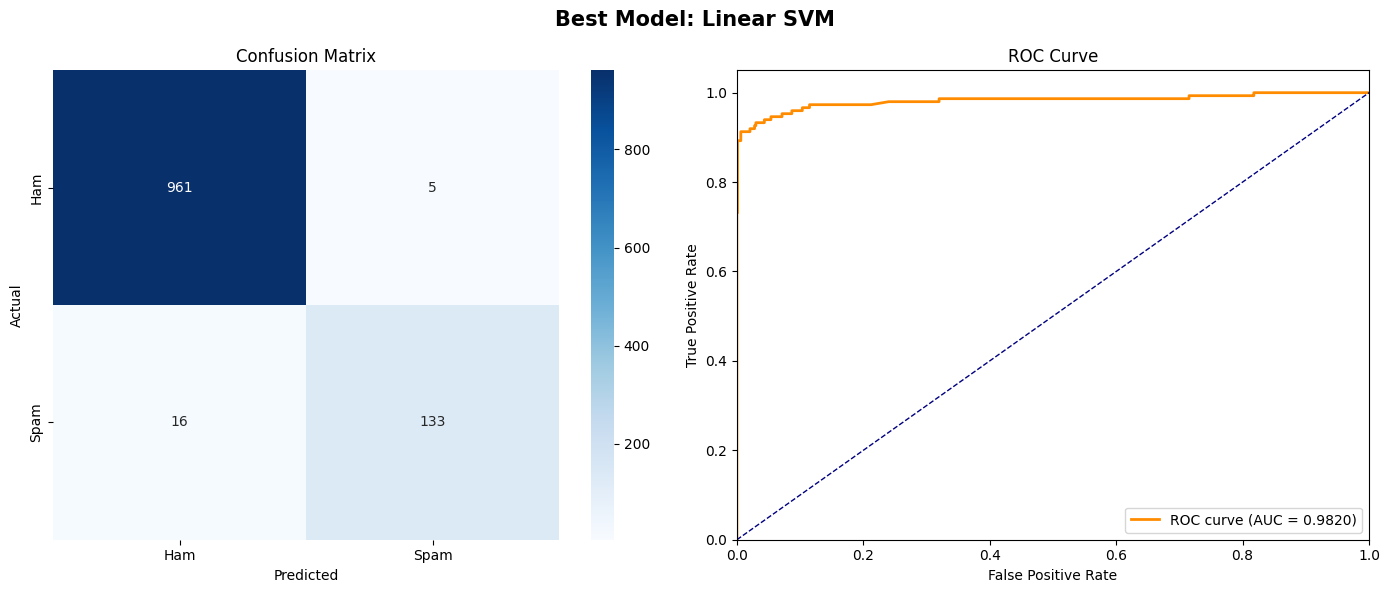

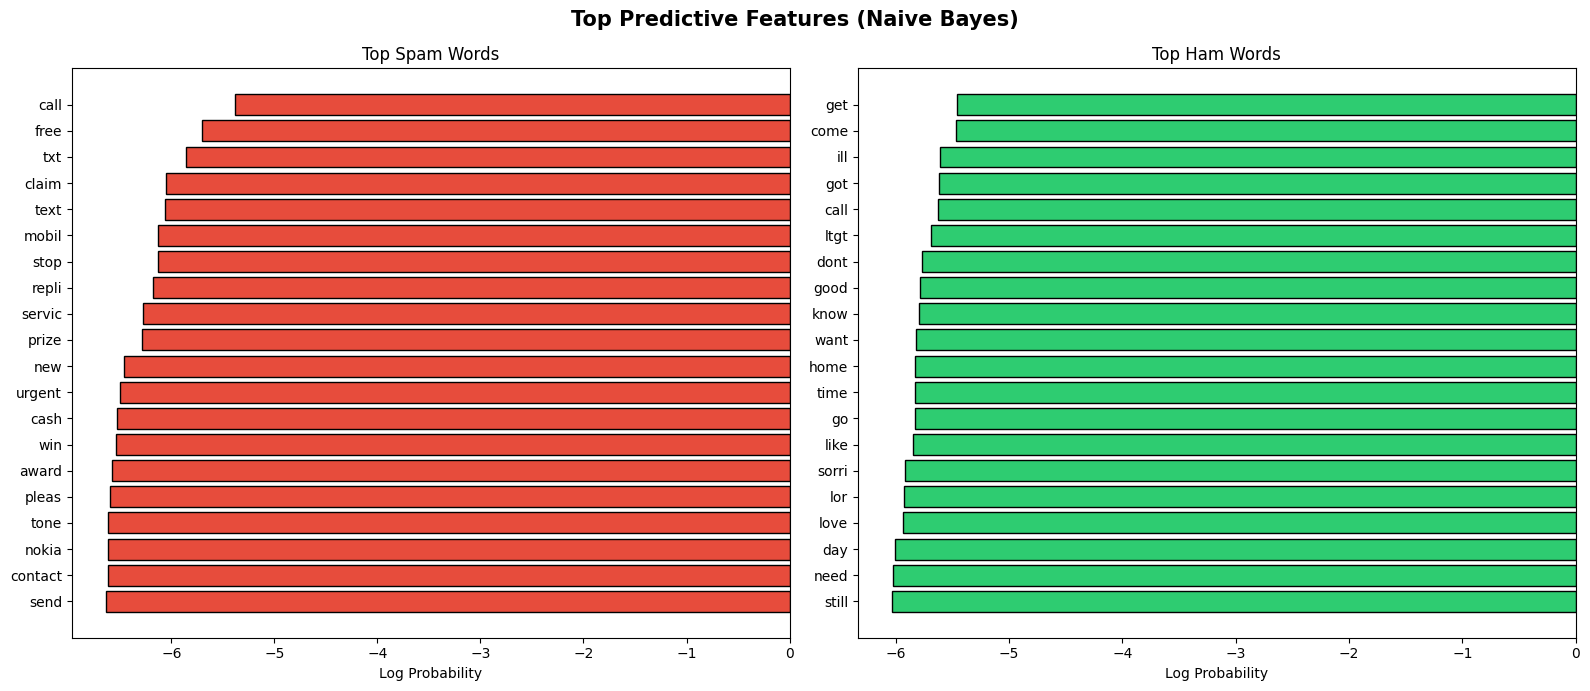

✅ Feature importance plotted!
🧪 SPAM CLASSIFIER - LIVE PREDICTIONS

📩 Message  : WINNER!! Claim your FREE £1000 prize NOW! Call 08712460324...
   Cleaned  : winner claim free prize call...
   Result   : 🚨 SPAM
   Confidence: 10.22%
-----------------------------------------------------------------

📩 Message  : Hey, are we still meeting for lunch tomorrow at noon?...
   Cleaned  : hey still meet lunch tomorrow noon...
   Result   : ✅ HAM
   Confidence: 15.84%
-----------------------------------------------------------------

📩 Message  : Congratulations! You've been selected for a $500 Walmart gift card. Cl...
   Cleaned  : congratul youv select walmart gift card click...
   Result   : ✅ HAM
   Confidence: 1.32%
-----------------------------------------------------------------

📩 Message  : Can you send me the project report by end of day?...
   Cleaned  : send project report end day...
   Result   : ✅ HAM
   Confidence: 4.65%
------------------------------------------------------------

In [1]:
# ============================================================
# 📧 SPAM EMAIL CLASSIFIER USING NLP
# Google Colab Ready | By: spam-email-classifier
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 1: Install Dependencies
# ─────────────────────────────────────────────────────────────
# Run this cell first in Colab
"""
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk wordcloud
"""

# ─────────────────────────────────────────────────────────────
# CELL 2: Import Libraries
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline

from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")


# ─────────────────────────────────────────────────────────────
# CELL 3: Load Dataset
# ─────────────────────────────────────────────────────────────
# Option A: Use UCI SMS Spam Collection Dataset (auto-download)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print(f"📦 Dataset Loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Option B: Upload your own CSV in Colab
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('your_file.csv')


# ─────────────────────────────────────────────────────────────
# CELL 4: Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# Class distribution
print("\n📌 Label Distribution:")
print(df['label'].value_counts())
print(f"\nSpam %: {df['label'].value_counts(normalize=True)['spam'] * 100:.2f}%")
print(f"Ham  %: {df['label'].value_counts(normalize=True)['ham'] * 100:.2f}%")

# Message length analysis
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("\n📏 Message Length Stats:")
print(df.groupby('label')[['message_length', 'word_count']].describe())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spam Email Classifier - EDA', fontsize=16, fontweight='bold')

# Plot 1: Class Distribution
colors = ['#2ecc71', '#e74c3c']
df['label'].value_counts().plot(kind='bar', ax=axes[0, 0], color=colors, edgecolor='black')
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_xlabel('Label')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Ham', 'Spam'], rotation=0)

# Plot 2: Pie Chart
df['label'].value_counts().plot(kind='pie', ax=axes[0, 1],
                                 autopct='%1.1f%%', colors=colors,
                                 labels=['Ham', 'Spam'], startangle=90)
axes[0, 1].set_title('Spam vs Ham Ratio')
axes[0, 1].set_ylabel('')

# Plot 3: Message Length Distribution
for label, color in zip(['ham', 'spam'], colors):
    df[df['label'] == label]['message_length'].hist(
        bins=50, ax=axes[1, 0], alpha=0.6, color=color, label=label
    )
axes[1, 0].set_title('Message Length Distribution')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Word Count Box Plot
df.boxplot(column='word_count', by='label', ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_title('Word Count by Label')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete!")


# ─────────────────────────────────────────────────────────────
# CELL 5: Word Cloud Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds: Spam vs Ham', fontsize=16, fontweight='bold')

for ax, label, cmap, title in zip(
    axes,
    ['spam', 'ham'],
    ['Reds', 'Greens'],
    ['🚨 Spam Messages', '✅ Ham Messages']
):
    text = ' '.join(df[df['label'] == label]['message'].tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word clouds generated!")


# ─────────────────────────────────────────────────────────────
# CELL 6: Text Preprocessing
# ─────────────────────────────────────────────────────────────
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove punctuation & special characters
    3. Tokenize
    4. Remove stopwords
    5. Stem words
    """
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10,}\b', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and stem
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print("⏳ Preprocessing messages...")
df['cleaned_message'] = df['message'].apply(preprocess_text)

print("\n📌 Sample Preprocessing Results:")
for i in range(3):
    print(f"\nOriginal : {df['message'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_message'].iloc[i]}")

print("\n✅ Text preprocessing complete!")


# ─────────────────────────────────────────────────────────────
# CELL 7: Feature Engineering & Label Encoding
# ─────────────────────────────────────────────────────────────
# Encode labels
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# Split features and target
X = df['cleaned_message']
y = df['label_encoded']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"   Spam in train: {y_train.sum()} | Spam in test: {y_test.sum()}")


# ─────────────────────────────────────────────────────────────
# CELL 8: Build & Compare Multiple Models
# ─────────────────────────────────────────────────────────────
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Define models
models = {
    'Naive Bayes (MNB)':        MultinomialNB(alpha=0.1),
    'Logistic Regression':      LogisticRegression(max_iter=1000, C=1.0),
    'Linear SVM':               LinearSVC(C=1.0, max_iter=1000),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print("=" * 60)
print("🔬 MODEL TRAINING & EVALUATION")
print("=" * 60)

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                   sublinear_tf=True, min_df=2, max_df=0.95)),
        ('clf', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # ROC-AUC (only for models with predict_proba or decision_function)
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
        else:
            y_prob = pipeline.decision_function(X_test)
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = None

    results[name] = {
        'pipeline': pipeline,
        'accuracy': acc,
        'auc': auc,
        'y_pred': y_pred,
        'y_prob': y_prob if auc else None
    }

    print(f"\n🔹 {name}")
    print(f"   Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    if auc:
        print(f"   ROC-AUC  : {auc:.4f}")
    print(f"   Report:\n{classification_report(y_test, y_pred, target_names=['Ham', 'Spam'])}")


# ─────────────────────────────────────────────────────────────
# CELL 9: Model Comparison Chart
# ─────────────────────────────────────────────────────────────
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
aucs = [results[m]['auc'] if results[m]['auc'] else 0 for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

# Accuracy
bars = axes[0].barh(model_names, accuracies, color='#3498db', edgecolor='black')
axes[0].set_xlim(0.9, 1.01)
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Accuracy')
for bar, val in zip(bars, accuracies):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# AUC
bars2 = axes[1].barh(model_names, aucs, color='#e74c3c', edgecolor='black')
axes[1].set_xlim(0.9, 1.01)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_xlabel('AUC Score')
for bar, val in zip(bars2, aucs):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison complete!")


# ─────────────────────────────────────────────────────────────
# CELL 10: Best Model – Confusion Matrix & ROC Curve
# ─────────────────────────────────────────────────────────────
# Select best model by accuracy
best_name = max(results, key=lambda x: results[x]['accuracy'])
best = results[best_name]
print(f"🏆 Best Model: {best_name} (Accuracy: {best['accuracy']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Model: {best_name}', fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
if best['y_prob'] is not None:
    fpr, tpr, _ = roc_curve(y_test, best['y_prob'])
    auc_val = roc_auc_score(y_test, best['y_prob'])
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {auc_val:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('best_model_results.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 11: Feature Importance – Top Spam/Ham Words
# ─────────────────────────────────────────────────────────────
# Fit Naive Bayes separately for interpretability
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', MultinomialNB())
])
nb_pipeline.fit(X_train, y_train)

feature_names = nb_pipeline.named_steps['tfidf'].get_feature_names_out()
log_probs = nb_pipeline.named_steps['clf'].feature_log_prob_

# Top features per class
top_n = 20
spam_top = np.argsort(log_probs[1])[-top_n:][::-1]
ham_top  = np.argsort(log_probs[0])[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top Predictive Features (Naive Bayes)', fontsize=15, fontweight='bold')

for ax, indices, title, color in zip(
    axes,
    [spam_top, ham_top],
    ['Top Spam Words', 'Top Ham Words'],
    ['#e74c3c', '#2ecc71']
):
    words = [feature_names[i] for i in indices]
    scores = [log_probs[1 if 'Spam' in title else 0][i] for i in indices]
    ax.barh(words[::-1], scores[::-1], color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Log Probability')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plotted!")


# ─────────────────────────────────────────────────────────────
# CELL 12: Interactive Prediction Function
# ─────────────────────────────────────────────────────────────
best_pipeline = best['pipeline']

def predict_spam(message: str) -> dict:
    """
    Predict whether an email/SMS is spam or ham.
    Returns label, confidence, and cleaned text.
    """
    cleaned = preprocess_text(message)
    prediction = best_pipeline.predict([cleaned])[0]
    label = '🚨 SPAM' if prediction == 1 else '✅ HAM'

    try:
        if hasattr(best_pipeline.named_steps['clf'], 'predict_proba'):
            proba = best_pipeline.predict_proba([cleaned])[0]
            confidence = proba[prediction] * 100
        else:
            decision = best_pipeline.decision_function([cleaned])[0]
            confidence = min(abs(decision) * 10, 100)
    except:
        confidence = None

    result = {
        'original':   message,
        'cleaned':    cleaned,
        'label':      label,
        'confidence': f"{confidence:.2f}%" if confidence else "N/A"
    }
    return result


# ─────────────────────────────────────────────────────────────
# CELL 13: Test the Classifier
# ─────────────────────────────────────────────────────────────
test_messages = [
    "WINNER!! Claim your FREE £1000 prize NOW! Call 08712460324",
    "Hey, are we still meeting for lunch tomorrow at noon?",
    "Congratulations! You've been selected for a $500 Walmart gift card. Click here!",
    "Can you send me the project report by end of day?",
    "FREE entry in 2 a weekly comp to win FA Cup final tkts 21st May 2005",
    "I'll be home late tonight, don't wait up for dinner.",
    "URGENT: Your account has been suspended. Verify now: http://bit.ly/fake",
    "Thanks for the birthday wishes! It was a great day.",
]

print("=" * 65)
print("🧪 SPAM CLASSIFIER - LIVE PREDICTIONS")
print("=" * 65)

for msg in test_messages:
    result = predict_spam(msg)
    print(f"\n📩 Message  : {result['original'][:70]}...")
    print(f"   Cleaned  : {result['cleaned'][:60]}...")
    print(f"   Result   : {result['label']}")
    print(f"   Confidence: {result['confidence']}")
    print("-" * 65)


# ─────────────────────────────────────────────────────────────
# CELL 14: Cross-Validation (Robustness Check)
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("🔄 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 50)

for name, model in list(models.items())[:3]:  # Top 3 for speed
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf', model)
    ])
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"\n🔹 {name}")
    print(f"   Scores : {[f'{s:.4f}' for s in cv_scores]}")
    print(f"   Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ─────────────────────────────────────────────────────────────
# CELL 15: Save the Best Model
# ─────────────────────────────────────────────────────────────
import pickle

model_filename = 'spam_classifier_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f"✅ Model saved as '{model_filename}'")

# Load and test
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

test_input = "Win a FREE iPhone 15! Click now!"
cleaned_test = preprocess_text(test_input)
pred = loaded_model.predict([cleaned_test])[0]
print(f"\n🔁 Loaded model test:")
print(f"   Input: '{test_input}'")
print(f"   Prediction: {'🚨 SPAM' if pred == 1 else '✅ HAM'}")

print("\n" + "=" * 60)
print("🎉 SPAM EMAIL CLASSIFIER COMPLETED SUCCESSFULLY!")
print("=" * 60)